This example was [contributed by Amadeusz Miszuda](https://github.com/phoebe-project/phoebe2/pull/902#issuecomment-3892950880)

In [1]:
import phoebe
from phoebe.features import Spot
from phoebe.parameters import FloatParameter, ParameterSet
from astropy import units as u
import numpy as np

b = phoebe.default_binary()
b.add_dataset('lc', compute_phases=phoebe.linspace(0,4,401))

b.add_constraint('semidetached', 'primary')
b.set_value('syncpar@primary', 1.5)

b.add_feature('spot', component='primary', relteff=1.1, radius=15, colat=90, long=30, feature='static_spot')
b.run_compute(model='with_static_spot')

b.disable_feature('static_spot')

class AsyncSpot(Spot):
    @classmethod
    def create_feature_parameters(self, feature, **kwargs):
        from phoebe.parameters.feature import spot
        from phoebe import u

        params = []
        ps, constraints = spot(feature, **kwargs)
        params = ps.to_list()

        params += [FloatParameter(qualifier='dlongdt',
                                  value=kwargs.get('dlongdt', 0.0),
                                  default_unit=u.deg/u.d,
                                  description='Time derivative of long')]
        params += [FloatParameter(qualifier='dcolatdt',
                                  value=kwargs.get('dcolatdt', 0.0),
                                  default_unit=u.deg/u.d,
                                  description='Time derivative of colat')]

        return ParameterSet(params), constraints
    
    @classmethod
    def parse_bundle(cls, b, feature_ps):
        from phoebe.features import Spot
        spot_kw = Spot.parse_bundle(b, feature_ps)
        addl_kw = cls.parse_from_feature_ps(b, feature_ps,
                                            [{'qualifier': 'dlongdt', 'unit': 'rad/d'},
                                             {'qualifier': 'dcolatdt', 'unit': 'rad/d'}])
        return dict(**spot_kw, **addl_kw)
  
    def instantaneous_position(self, s, time):
        """
        s is the spin vector in roche coordinates
        time is the current time
        """
        t = time - self.kwargs['t0']
        longitude = self.kwargs['longitude'] + (self.kwargs['rot_dlongdt'] + self.kwargs['dlongdt']) * t
        colat = self.kwargs['colat'] + self.kwargs['dcolatdt'] * t
        return longitude, colat

dlongdt = (1 - b.get_value('syncpar@primary@component')) * 360.0 * u.deg / (b.get_value('period@binary') * u.day) 

b.add_dataset('mesh', compute_phases=phoebe.linspace(0,3,151), columns='intensities*')
b.add_feature(AsyncSpot, component='primary', relteff=1.1, radius=15, colat=90, long=30, dlongdt=dlongdt, feature='asynchronous_spot', overwrite=True)
b.run_compute(model='with_asynchronous_spot', overwrite=True)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 401/401 [00:07<00:00, 51.90it/s]


<ParameterSet: 1515 parameters | kinds: mesh, lc>

In [2]:
_ = b.plot(kind='mesh', animate=True, fc='intensities@lc01', ec='face', save='./mesh_async_spot.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


![mesh anim](mesh_async_spot.gif)

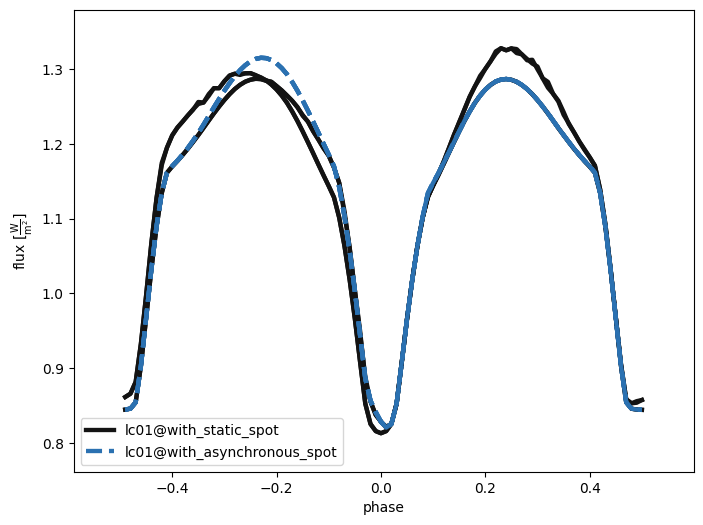

In [4]:
_ = b.plot(x='phase', kind='lc', show=True, legend=True)